# Разработка A/B-тестирования и анализ результатов



## Описание данных



- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. 

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. 

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. 


Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).




In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from math import *
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [10]:
session_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')
session_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [11]:
single_user_id = session_history.groupby('user_id').agg({'session_id' : 'nunique'}).sort_values(by = 'session_id', ascending = False).index[0]
print(session_history[session_history.user_id == single_user_id])

                 user_id        session_id session_date     session_start_ts  \
115558  10E0DEFC1ABDBBE0  B8F0423BBFFCF5DC   2025-08-14  2025-08-14 13:57:39   
191751  10E0DEFC1ABDBBE0  87CA2FA549473837   2025-08-15  2025-08-15 16:42:10   
239370  10E0DEFC1ABDBBE0  4ADD8011DCDCE318   2025-08-16  2025-08-16 19:53:21   
274629  10E0DEFC1ABDBBE0  DF0FD0E09BF1F3D7   2025-08-17  2025-08-17 15:03:43   
302501  10E0DEFC1ABDBBE0  3C221774B4DE6885   2025-08-18  2025-08-18 17:29:14   
325557  10E0DEFC1ABDBBE0  031BD7A67048105B   2025-08-19  2025-08-19 13:23:55   
345336  10E0DEFC1ABDBBE0  FF4315CF4AD4B100   2025-08-20  2025-08-20 19:31:54   
377532  10E0DEFC1ABDBBE0  4045FEA0747203B4   2025-08-22  2025-08-22 17:54:13   
403538  10E0DEFC1ABDBBE0  344B086C421C7F37   2025-08-24  2025-08-24 14:46:13   
414743  10E0DEFC1ABDBBE0  054F20BA371E4C9D   2025-08-25  2025-08-25 18:36:41   

       install_date  session_number  registration_flag  page_counter region  \
115558   2025-08-14               1     

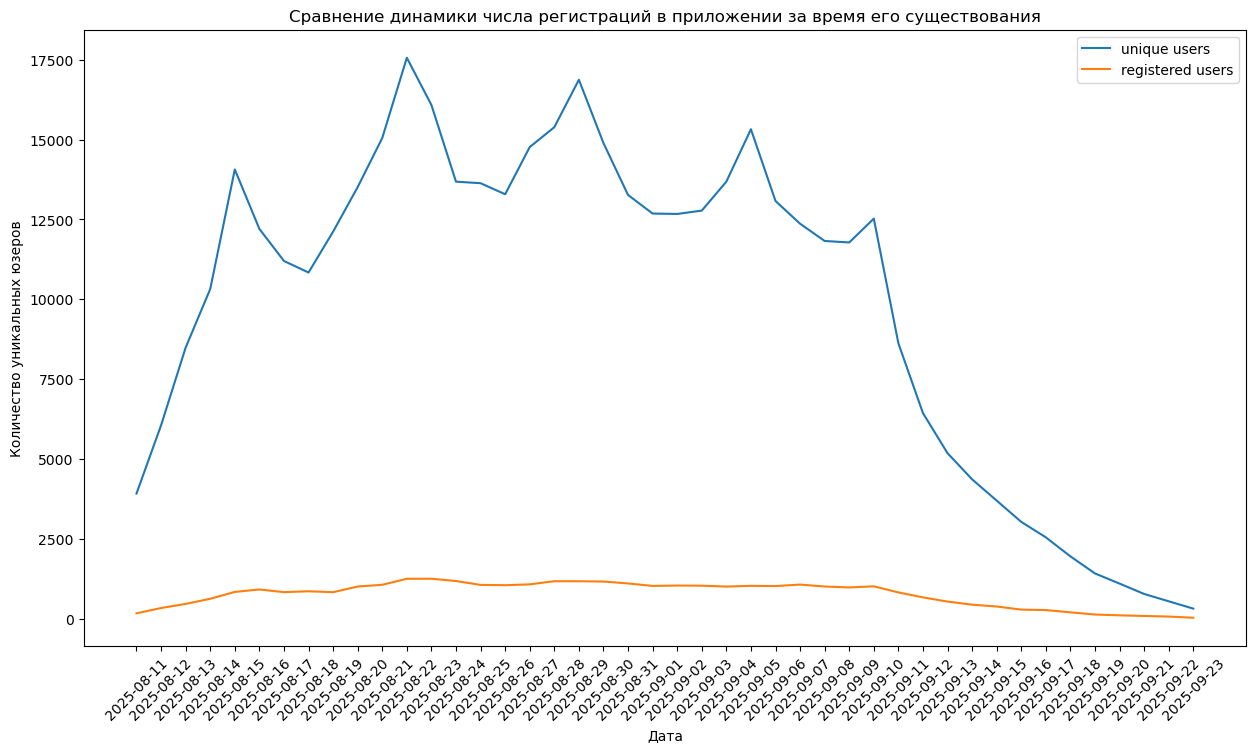

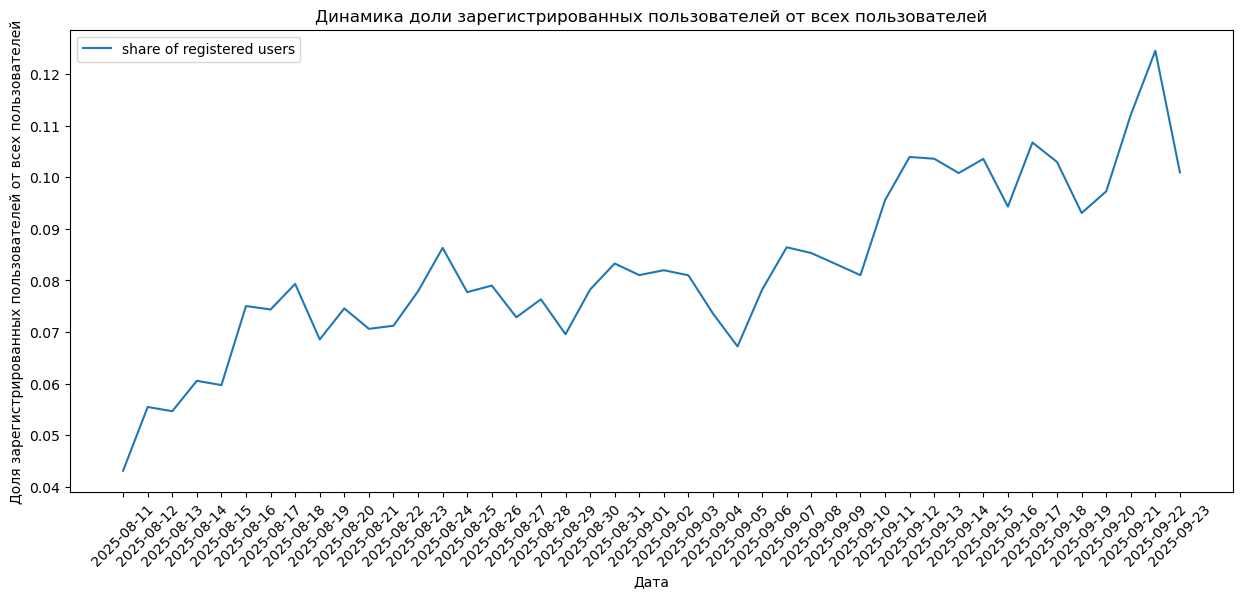

In [12]:
unique_users = session_history.groupby('session_date').agg(unique = ('user_id','nunique')).reset_index()
registrated_users = session_history[session_history.registration_flag == 1].groupby('session_date').agg(registrated = ('user_id','nunique')).reset_index()

x = unique_users['session_date']
y_1 = unique_users['unique']
y_2 = registrated_users['registrated']
y_3 = y_2 / y_1


plt.figure(figsize=(15, 8))
plt.plot(x, y_1, label='unique users')
plt.plot(x, y_2, label='registered users')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных юзеров")
plt.xticks(rotation=45)
plt.legend()
plt.title('Сравнение динамики числа регистраций в приложении за время его существования') 
plt.show()


plt.figure(figsize=(15, 6))
plt.plot(x, y_3, label='share of registered users')

plt.xlabel("Дата")
plt.ylabel("Доля зарегистрированных пользователей от всех пользователей")
plt.xticks(rotation=45)
plt.legend()
plt.title('Динамика доли зарегистрированных пользователей от всех пользователей')
plt.show()

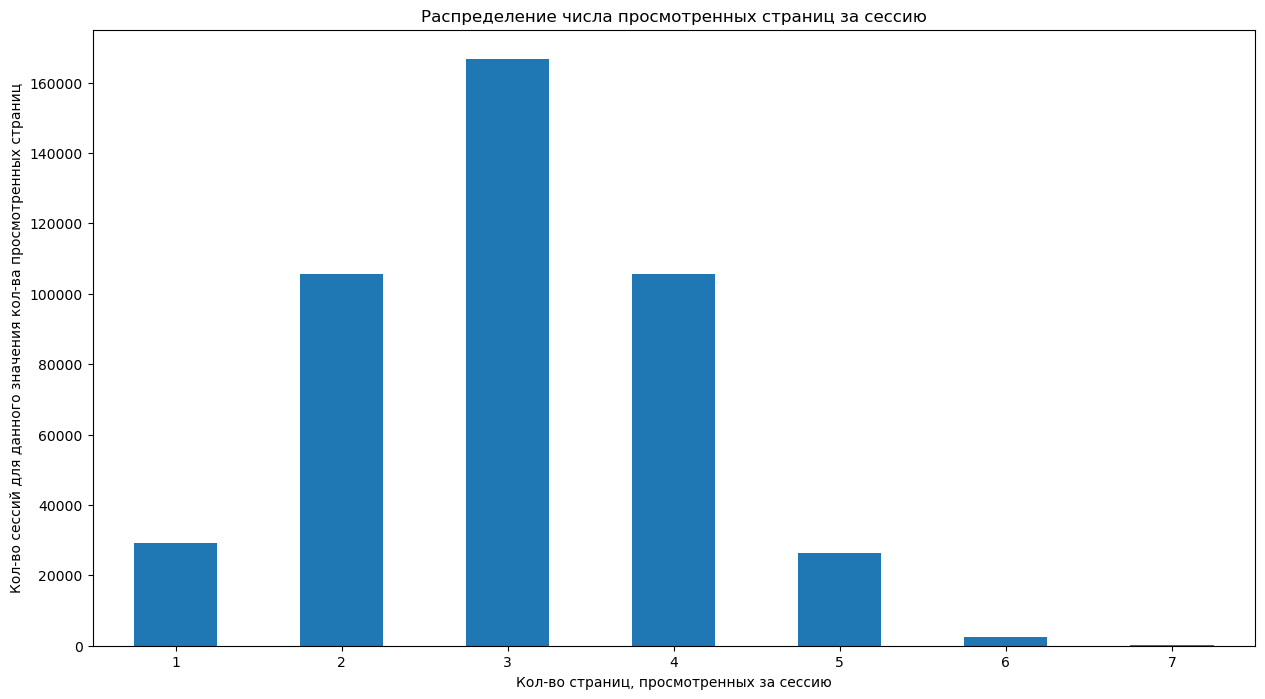

In [13]:
looked_pages = session_history.page_counter.value_counts().sort_index()

plt.figure(figsize=(15,8))
looked_pages.plot(kind = 'bar')
plt.xticks(rotation=0)
plt.xlabel("Кол-во страниц, просмотренных за сессию")
plt.ylabel("Кол-во сессий для данного значения кол-ва просмотренных страниц")
plt.title('Распределение числа просмотренных страниц за сессию')
plt.show()

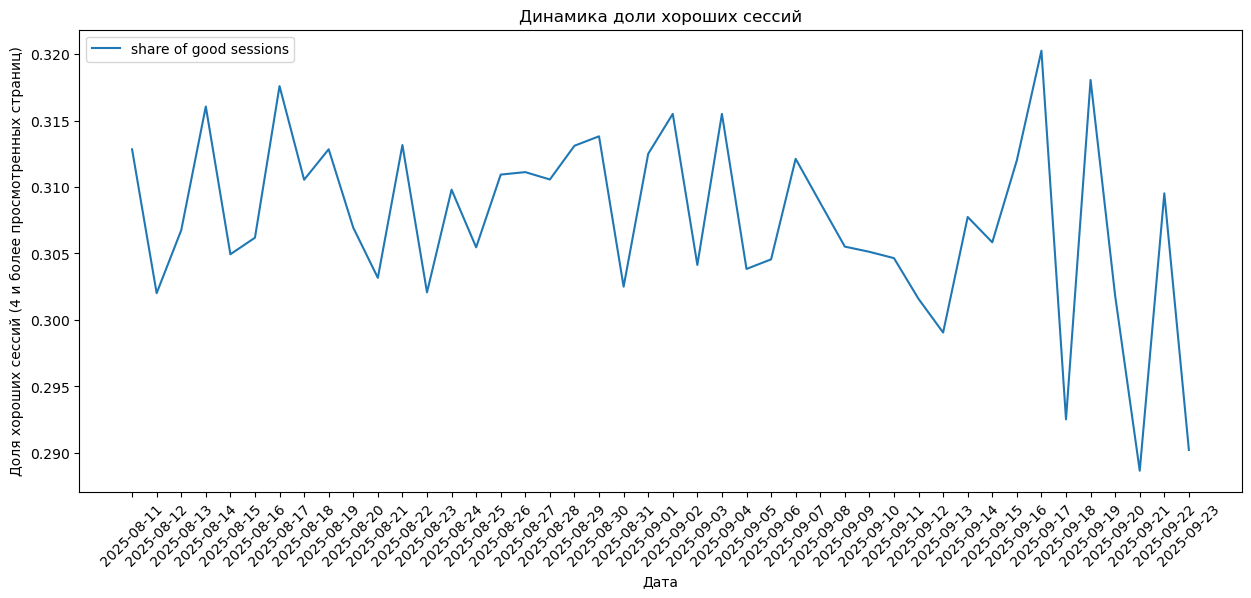

In [14]:
session_history['good_session'] = 0
session_history.loc[session_history.page_counter >= 4, 'good_session'] = 1

good_sessions = session_history.groupby('session_date').agg(amnt_good_sessions = ('good_session', 'sum'))
all_sessions = session_history.groupby('session_date').agg(amnt_all_sessions = ('session_id', 'nunique'))

share_of_good_sessions = good_sessions['amnt_good_sessions'] / all_sessions['amnt_all_sessions']

plt.figure(figsize=(15, 6))
plt.plot(x, share_of_good_sessions, label='share of good sessions')

plt.xlabel("Дата")
plt.ylabel("Доля хороших сессий (4 и более просмотренных страниц)")
plt.xticks(rotation=45)
plt.legend()
plt.title('Динамика доли хороших сессий')
plt.show()

Целевой метрикой выберу долю успешных сессий

In [15]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
mde = 0.03  # Минимальный детектируемый эффект

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = mde,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 17441


In [16]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(session_history.groupby('session_date').agg({'user_id':'nunique'})['user_id'].mean())


# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 4 дней


Процентная разница в количестве пользователей в группах A и B составляет 0.74 %


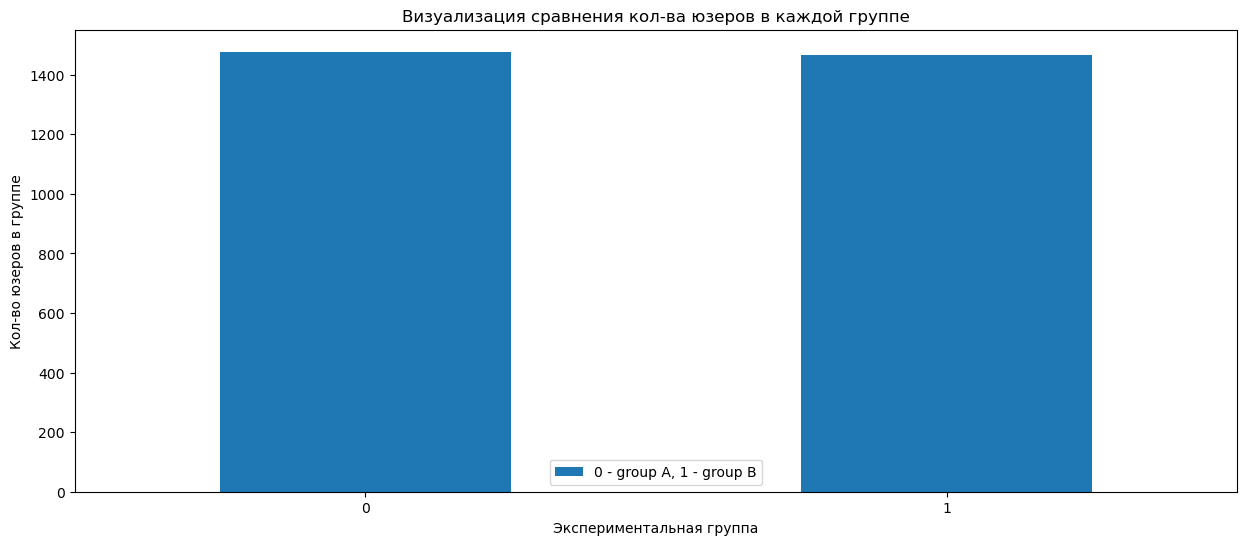

In [17]:
session_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

groups = session_test_part.groupby('test_group').agg({'user_id':'nunique'}).reset_index()
group_A = groups.loc[0, 'user_id']
group_B = groups.loc[1, 'user_id']

diff = 100 * abs(group_A - group_B) / group_A
print(f'Процентная разница в количестве пользователей в группах A и B составляет {round(diff, 2)} %')


plt.figure(figsize = (15,6))
groups['user_id'].plot(kind = 'bar', label = '0 - group A, 1 - group B')
plt.xlabel("Экспериментальная группа")
plt.ylabel("Кол-во юзеров в группе")
plt.xticks(rotation=0)
plt.legend()
plt.title('Визуализация сравнения кол-ва юзеров в каждой группе')
plt.show()


In [18]:
group_A_user_id = session_test_part[session_test_part['test_group'] == 'A']['user_id']
group_B_user_id = session_test_part[session_test_part['test_group'] == 'B']['user_id']


intersection = list(set(group_A_user_id) & set(group_B_user_id))
print(intersection)

[]


Пересечение является пустым множеством, значит нет пользователей, которые бы попали в обе тестовые группы

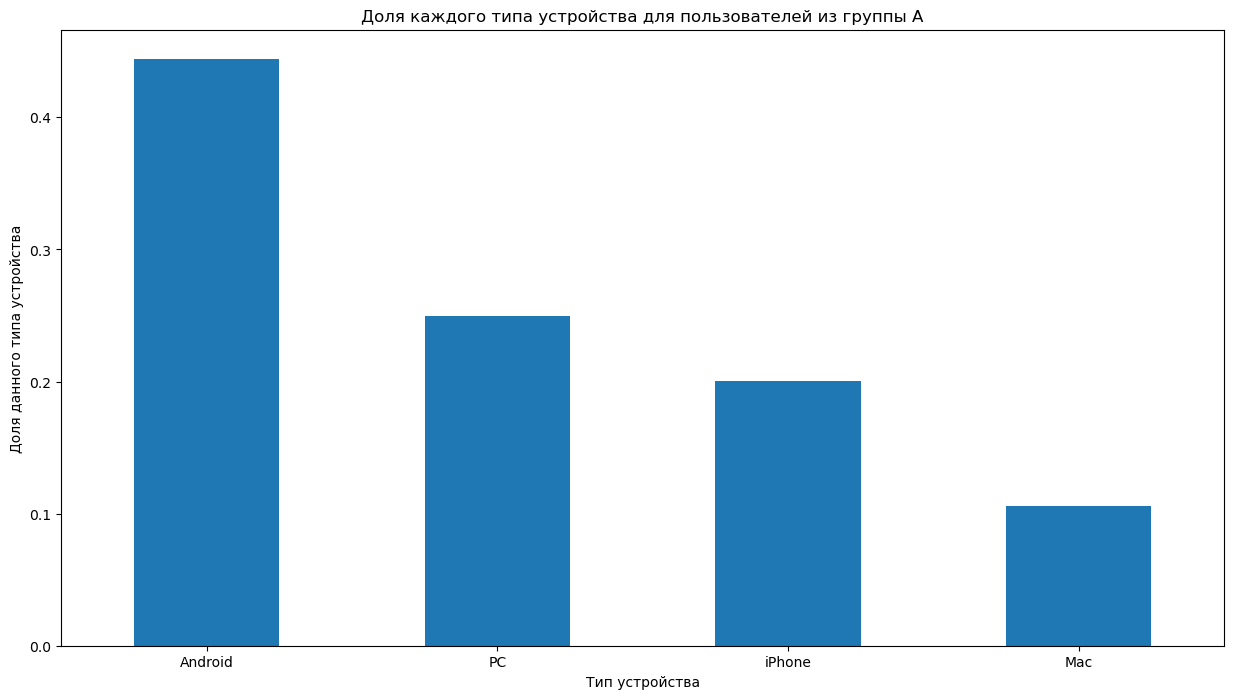

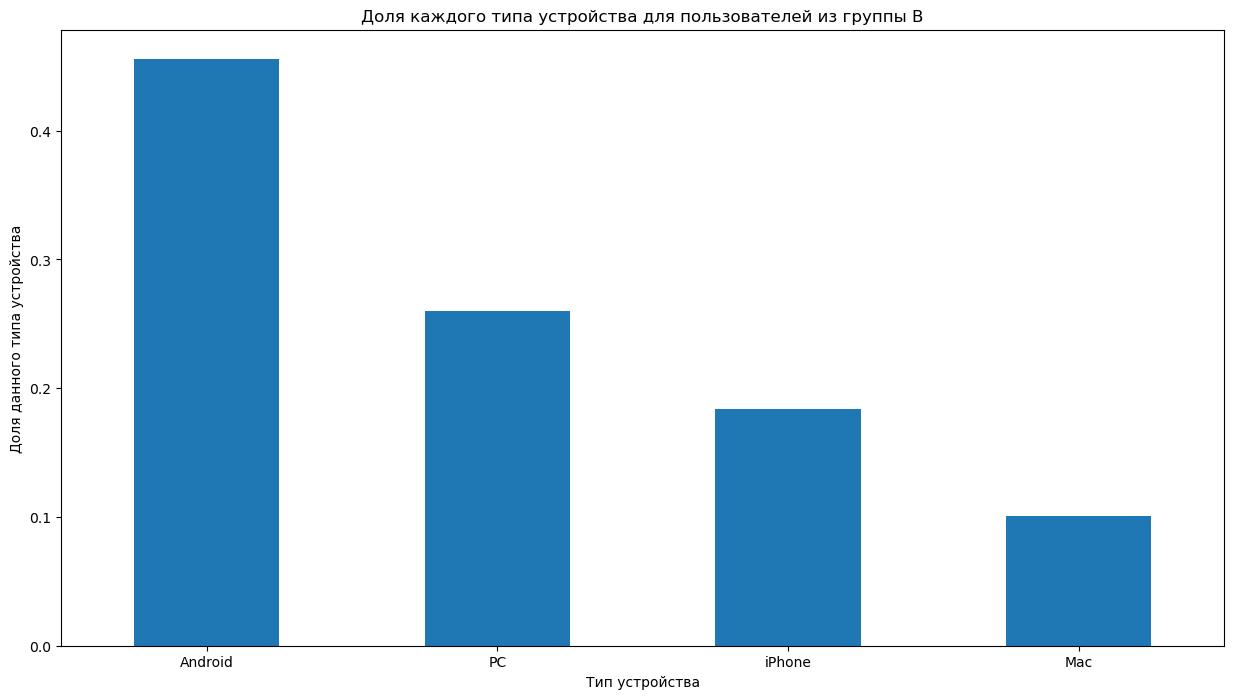

In [19]:
devices_group_A = session_test_part[session_test_part['test_group'] == 'A'].drop_duplicates(subset='user_id')['device'].value_counts() 
df_len_group_a = session_test_part[session_test_part['test_group'] == 'A'].drop_duplicates(subset='user_id').shape[0]
devices_group_A = devices_group_A / df_len_group_a

plt.figure(figsize = (15,8))
devices_group_A.plot(kind = 'bar')
plt.xlabel("Тип устройства")
plt.ylabel("Доля данного типа устройства")
plt.xticks(rotation=0)
plt.title('Доля каждого типа устройства для пользователей из группы A')
plt.show()

devices_group_B = session_test_part[session_test_part['test_group'] == 'B'].drop_duplicates(subset='user_id')['device'].value_counts()
df_len_group_b = session_test_part[session_test_part['test_group'] == 'B'].drop_duplicates(subset='user_id').shape[0]
devices_group_B = devices_group_B / df_len_group_b

plt.figure(figsize = (15,8))
devices_group_B.plot(kind = 'bar')
plt.xlabel("Тип устройства")
plt.ylabel("Доля данного типа устройства")
plt.xticks(rotation=0)
plt.title('Доля каждого типа устройства для пользователей из группы B')
plt.show()

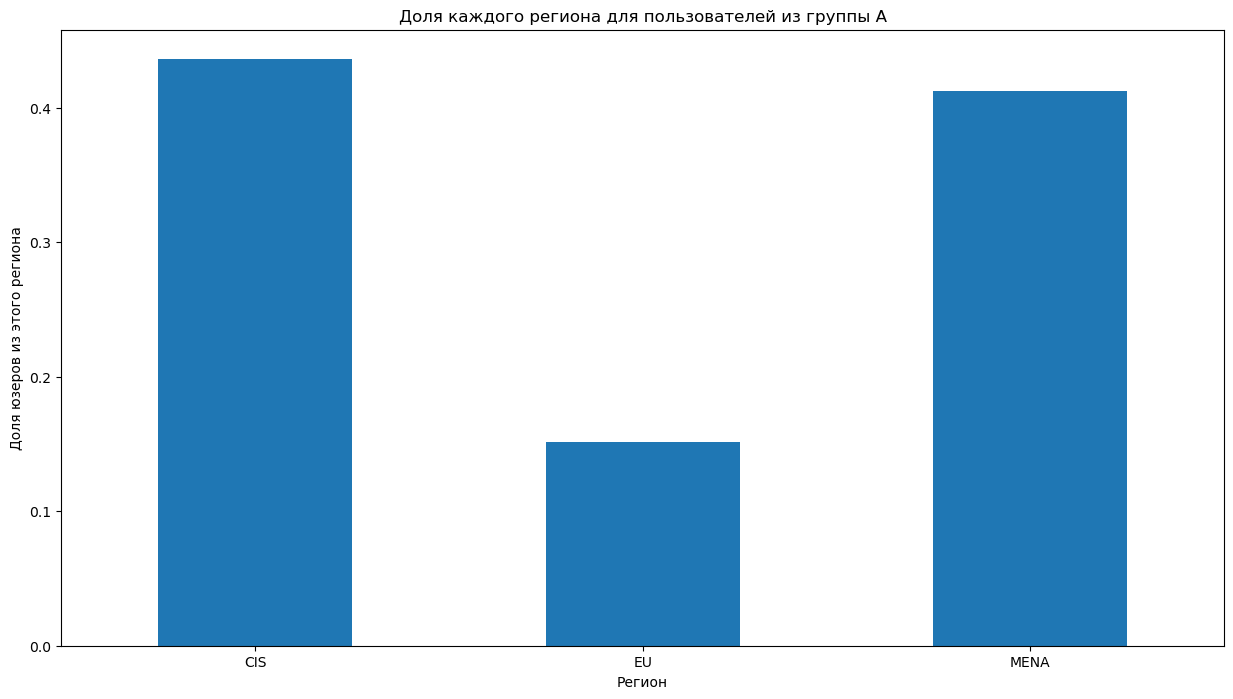

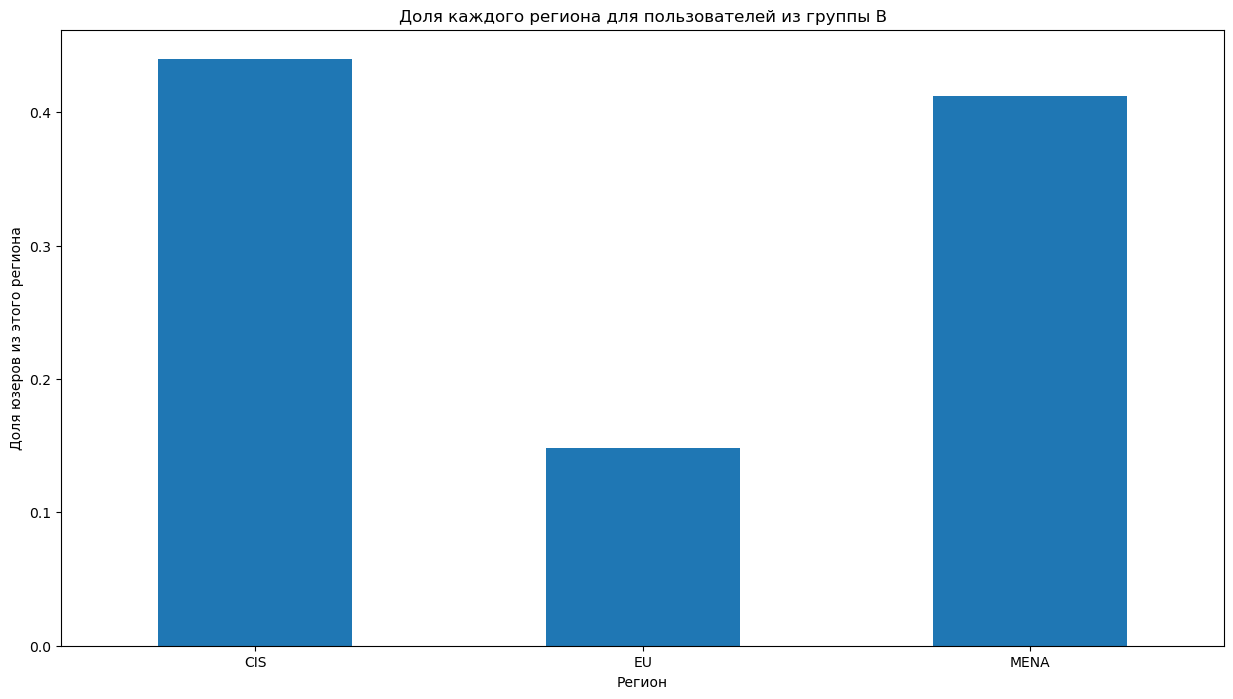

In [20]:
region_group_A = session_test_part[session_test_part['test_group'] == 'A'].drop_duplicates(subset='user_id')['region'].value_counts().sort_index()
region_group_A = region_group_A / df_len_group_a

plt.figure(figsize = (15,8))
region_group_A.plot(kind = 'bar')
plt.xlabel("Регион")
plt.ylabel("Доля юзеров из этого региона")
plt.xticks(rotation=0)
plt.title('Доля каждого региона для пользователей из группы A')
plt.show()

region_group_B = session_test_part[session_test_part['test_group'] == 'B'].drop_duplicates(subset='user_id')['region'].value_counts().sort_index()
region_group_B = region_group_B / df_len_group_b

plt.figure(figsize = (15,8))
region_group_B.plot(kind = 'bar')
plt.xlabel("Регион")
plt.ylabel("Доля юзеров из этого региона")
plt.xticks(rotation=0)
plt.title('Доля каждого региона для пользователей из группы В')
plt.show()

1) В группе А 1477 юзеров, в группе В - 1466. Процентная разница составляет 0,74%. Можно сказать, что с хорошей степенью точности кол-во юзеров в каждой из групп одинаково

2) Пересечения пользователей из тестовой и контрольной групп не обнаружено

3) Распределение по устройствам и регионам остается равномерным для обеих групп. 

In [21]:
session_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')
session_test['good_session'] = 0
session_test.loc[session_test.page_counter >= 4, 'good_session'] = 1

In [22]:
unique_sessions_group_A = session_test[session_test['test_group'] == 'A'].groupby('session_date').agg({'session_id':'nunique'})

unique_sessions_group_B = session_test[session_test['test_group'] == 'B'].groupby('session_date').agg({'session_id':'nunique'})

metric_a = unique_sessions_group_A['session_id']
metric_b = unique_sessions_group_B['session_id']

alpha = 0.05

stat_ttest, p_value_ttest = ttest_ind(
    metric_a, 
    metric_b, 
    alternative='two-sided')

if p_value_ttest > alpha:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! ')
    print('Интерпретация: группы А и В сопоставимы по кол-ву ')
else:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны')
    print('Интерпретация: новый алгоритм увеличил кол-во сессий')

p-value теста Стьюдента =0.94
Нулевая гипотеза находит подтверждение! 
Интерпретация: группы А и В сопоставимы по кол-ву 


In [23]:
good_sessions_share_A = session_test[session_test['test_group'] == 'A']['good_session'].sum() / session_test[session_test['test_group'] == 'A']['session_id'].nunique()
print(f'Доля успешных сессий для выборки А составляет {round(good_sessions_share_A, 4)}')
good_sessions_share_B = session_test[session_test['test_group'] == 'B']['good_session'].sum() / session_test[session_test['test_group'] == 'B']['session_id'].nunique() 
print(f'Доля успешных сессий для выборки В составляет {round(good_sessions_share_B,4)}')
print(f'Разница показателей составляет {round(round(good_sessions_share_B,4) - round(good_sessions_share_A, 4),4)}')

Доля успешных сессий для выборки А составляет 0.3077
Доля успешных сессий для выборки В составляет 0.3183
Разница показателей составляет 0.0106


In [24]:
n_a = session_test[session_test['test_group'] == 'A'].shape[0]
n_b = session_test[session_test['test_group'] == 'B'].shape[0]

m_a = session_test[session_test['test_group'] == 'A']['good_session'].sum()
m_b = session_test[session_test['test_group'] == 'B']['good_session'].sum()

alpha = 0.05 

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' 
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')
print('Интерпертация: изменения в кол-ве успешных сессий статистически значимые!')

pvalue=0.0001574739988036123 < 0.05
Нулевая гипотеза не находит подтверждения!
Интерпертация: изменения в кол-ве успешных сессий статистически значимые!


Для A/B теста необходимо было задействовать 17441 пользователей в каждой группе, рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 4 дня (в файле были предоставленны данные за 20 дней)

Тестирование проводилось для одинаковых по размеру, равнораспределенных тестовой и контрольной групп, далее группы А и В.

pvalue для оценки стат. значимости выявленного эффекта составило 0.000157, что меньше уровня значимости = 0.05

Таким образом, новый алгоритм увеличил количество сессий, у которых число просмотренных страниц больше или равно 4, а значит нововведение стоит внедрять в приложение
